### Notebook modelo de árbol de decisión y vecinos cercanos

En esta sesión nos concentraremos en la aplicación práctica de ambos modelos usando un pequeño conjunto de datos de habitabilidad de exoplanetas.

**Objetivos:**
- entrenar un **árbol de decisión** y un clasificador **kNN** con `scikit-learn`,
- interpretar predicciones y calcular `accuracy`,
- comparar ambos métodos en un mismo problema,
- entender por qué **kNN requiere escalamiento** de variables y los árboles no necesariamente.


(Adaptado de  Viviana Acquaviva (2023))



## Decision Trees

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


https://www.kaggle.com/code/willkoehrsen/visualize-a-decision-tree-w-python-scikit-learn

In [76]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd 

In [77]:
font = {'size'   : 20}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
matplotlib.rcParams['figure.dpi'] = 300

In [78]:
#Paquetes para visualización

from io import StringIO
from IPython.display import Image  
import pydotplus

from sklearn.tree import export_graphviz 

### Subconjunto de base de datos de Habitabilidad de planetas https://phl.upr.edu/projects/habitable-exoplanets-catalog

In [79]:
LearningSet = pd.read_csv('HPLearningSet.csv', index_col=0)

**Variables:**
- `S_MASS`: masa estelar ($M_\odot$)
- `P_PERIOD`: período orbital (días)
- `P_DISTANCE`: distancia planeta–estrella (AU)
- `P_HABITABLE`: clase objetivo (0 = no habitable, 1 = habitable)


In [80]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


### Haga una revisión rápida del set de datos
- Encuentre el tamaño del dataset, y las categorías de la variable `P_HABITABLE` y los ejemplos en cada categoría.
- También visualice la relación entre la masa, el periodo y la habitabilidad del planeta. Grafique el periodo en escala log

In [81]:
print("Tamaño dataset:", LearningSet.shape)


Tamaño dataset: (18, 5)


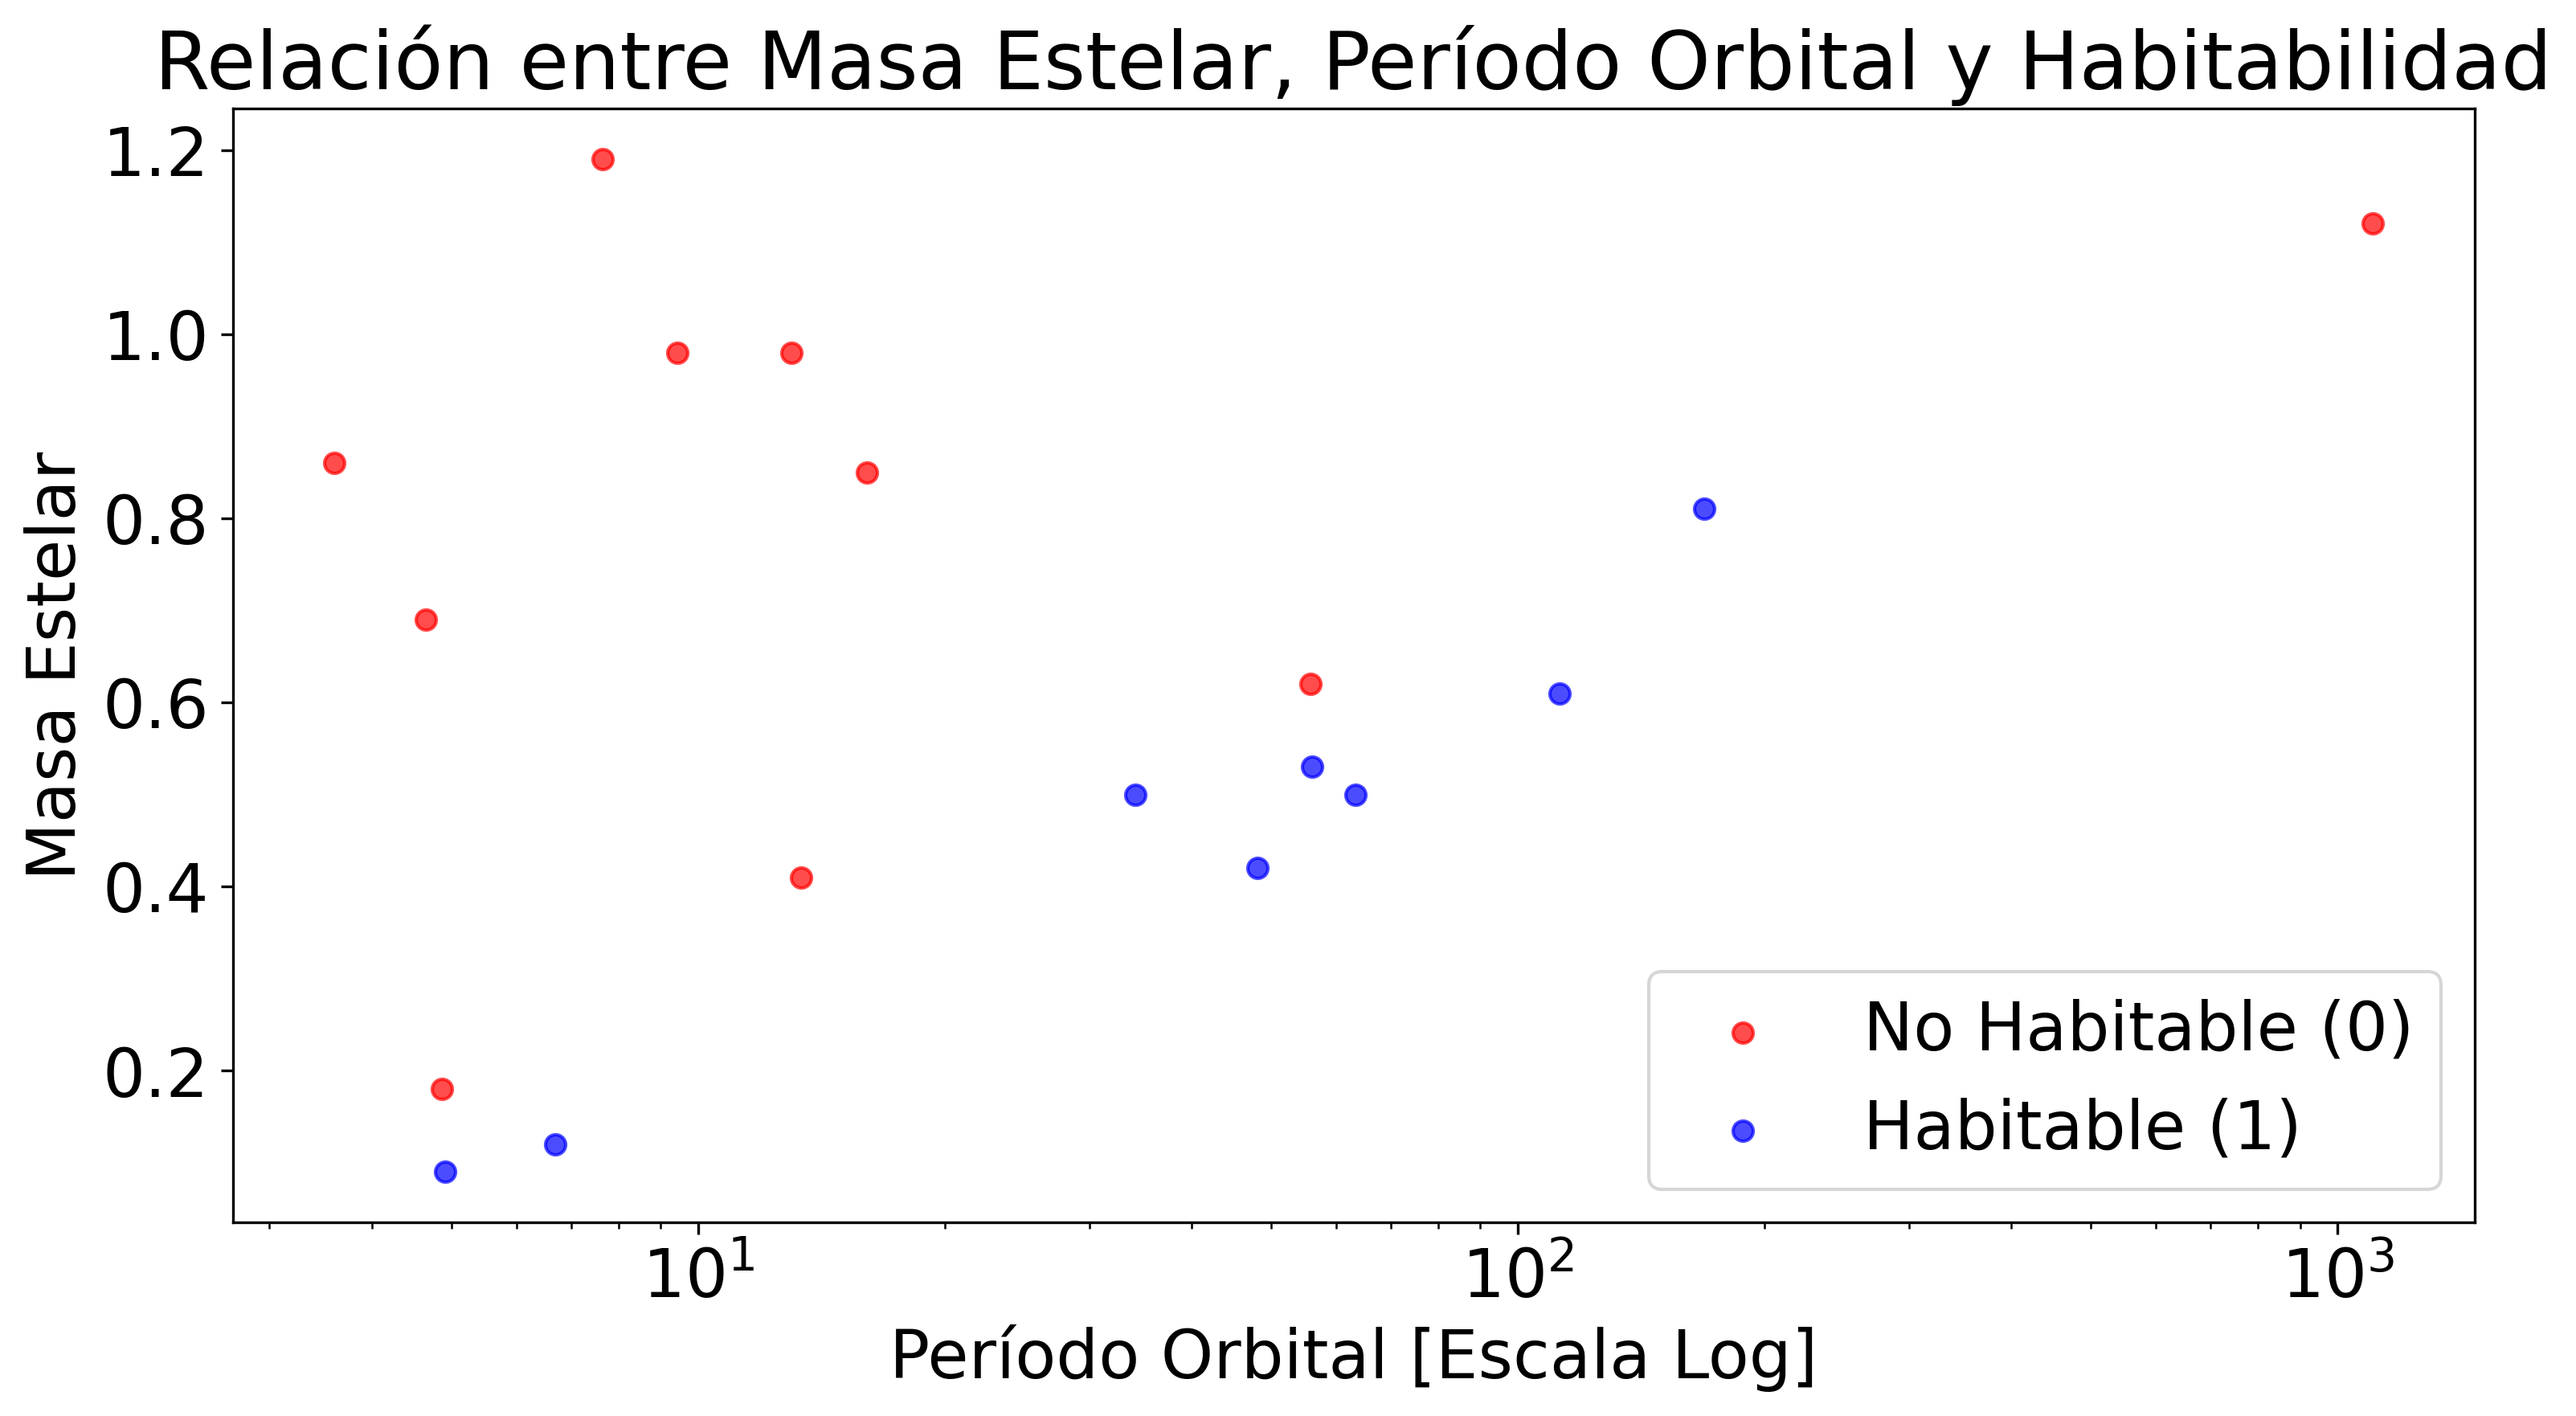

In [82]:
plt.figure(figsize=(12, 6))

habitable = LearningSet[LearningSet['P_HABITABLE'] == 1]
no_habitable = LearningSet[LearningSet['P_HABITABLE'] == 0]

plt.scatter(no_habitable['P_PERIOD'], no_habitable['S_MASS'], 
            color='red', label='No Habitable (0)', alpha=0.7)

plt.scatter(habitable['P_PERIOD'], habitable['S_MASS'], 
            color='blue', label='Habitable (1)', alpha=0.7)

plt.xscale('log')

plt.xlabel('Período Orbital [Escala Log]')
plt.ylabel('Masa Estelar')
plt.title('Relación entre Masa Estelar, Período Orbital y Habitabilidad')
plt.legend()
plt.show()

**Antes de entrenar un modelo, te parece que las clases se separan fácilmente o no? Explique**


Al mirar el gráfico, se nota que las clases no se pueden separar con una línea recta. Los planetas habitables (azules) se agrupan en ciertas combinaciones específicas de masa estelar y período orbital, que corresponden a la zona habitable de la estrella.

### Elijamos el set de entrenamiento y prueba

Para definir los sets de etrenamiento y prueba, haremos una división *manual*

Definimos que las primeras 13 filas del dataframe será el conjunto de entrenamiento y los últimos 5, el conjunto de prueba

> En un problema real, usualmente preferimos una división aleatoria o validación cruzada.


Usaremos .iloc para acceder a los índices del dataframe

In [83]:
LearningSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [84]:
TrainSet =  LearningSet.iloc[:13,:]  
TestSet = LearningSet.iloc[13:,:]

In [85]:
TrainSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
0,Kepler-736 b,0.86,3.601472,0.043718,0
1,Kepler-636 b,0.85,16.080661,0.118082,0
2,Kepler-887 c,1.19,7.638460,0.080420,0
3,Kepler-442 b,0.61,112.305300,0.409327,1
4,Kepler-772 b,0.98,12.992073,0.107408,0
5,Teegarden's Star b,0.09,4.910000,0.025200,1
6,K2-116 b,0.69,4.655411,0.048086,0
7,GJ 1061 c,0.12,6.689000,0.035000,1
8,HD 68402 b,1.12,1103.000000,2.180981,0
9,Kepler-1544 b,0.81,168.811170,0.557107,1


In [86]:
TestSet

,P_NAME,S_MASS,P_PERIOD,P_DISTANCE,P_HABITABLE
13,HD 104067 b,0.62,55.80600,0.260000,0
14,GJ 4276 b,0.41,13.35200,0.087613,0
15,Kepler-296 f,0.50,63.33627,0.268885,1
16,Kepler-63 b,0.98,9.43415,0.088100,0
17,GJ 3293 d,0.42,48.13450,0.195336,1


También necesitamos definir para cada conjunto las características (features) y los objetivos (targets)

In [87]:
Xtrain = TrainSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features conjunto de entrenamiento
Xtest = TestSet.drop(['P_NAME','P_HABITABLE'],axis=1) #features  conjunto de entrenamiento

In [88]:
Xtrain.columns

Index(['S_MASS', 'P_PERIOD', 'P_DISTANCE'], dtype='object')

In [89]:
ytrain = TrainSet.P_HABITABLE #target conjunto prueba
ytest = TestSet.P_HABITABLE  #target conjunto prueba

In [90]:
Xtest

,S_MASS,P_PERIOD,P_DISTANCE
13,0.62,55.80600,0.260000
14,0.41,13.35200,0.087613
15,0.50,63.33627,0.268885
16,0.98,9.43415,0.088100
17,0.42,48.13450,0.195336


In [91]:
ytrain

0     0
1     0
2     0
3     1
4     0
5     1
6     0
7     1
8     0
9     1
10    1
11    1
12    0
Name: P_HABITABLE, dtype: int64

### Entrenamos el modelo
Nota: En los árboles de decisión de scikit-learn, las características (o variables) se reorganizan aleatoriamente cada vez que se realiza una división para decidir cómo separar los datos. Esto significa que, incluso si se usa el mismo conjunto de datos de entrenamiento, la mejor forma de dividir los datos puede cambiar entre diferentes ejecuciones del modelo. Esta variación ocurre cuando varias divisiones posibles ofrecen la misma mejora en el criterio de evaluación (por ejemplo, reducir la impureza del nodo). En estos casos, el algoritmo puede elegir diferentes divisiones como "mejores" en diferentes ejecuciones debido al orden aleatorio en que se evalúan las características.

Para asegurar que los resultados del entrenamiento sean consistentes y reproducibles (es decir, que se obtenga el mismo árbol de decisión cada vez que se entrene con los mismos datos), es necesario fijar el parámetro random_state. Esto establece una semilla para el generador de números aleatorios utilizado por el algoritmo, garantizando que la permutación de las características sea la misma en cada ejecución y, por lo tanto, el resultado del modelo también sea el mismo.

In [92]:
from sklearn.tree import DecisionTreeClassifier #modelo de árbol de decisión

In [93]:
model = DecisionTreeClassifier(random_state = 3) #Inicializamos el modelo con sus parámetros
model.fit(Xtrain, ytrain) #En una línea, construimos el modelo

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,3
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Podemos visualizar el árbol (visualización "pro")

debe instalar la libreria [`pydotplus`](https://pypi.org/project/pydotplus/)  y [`graphviz`](https://pypi.org/project/graphviz/) 

### Visualización de sklearn

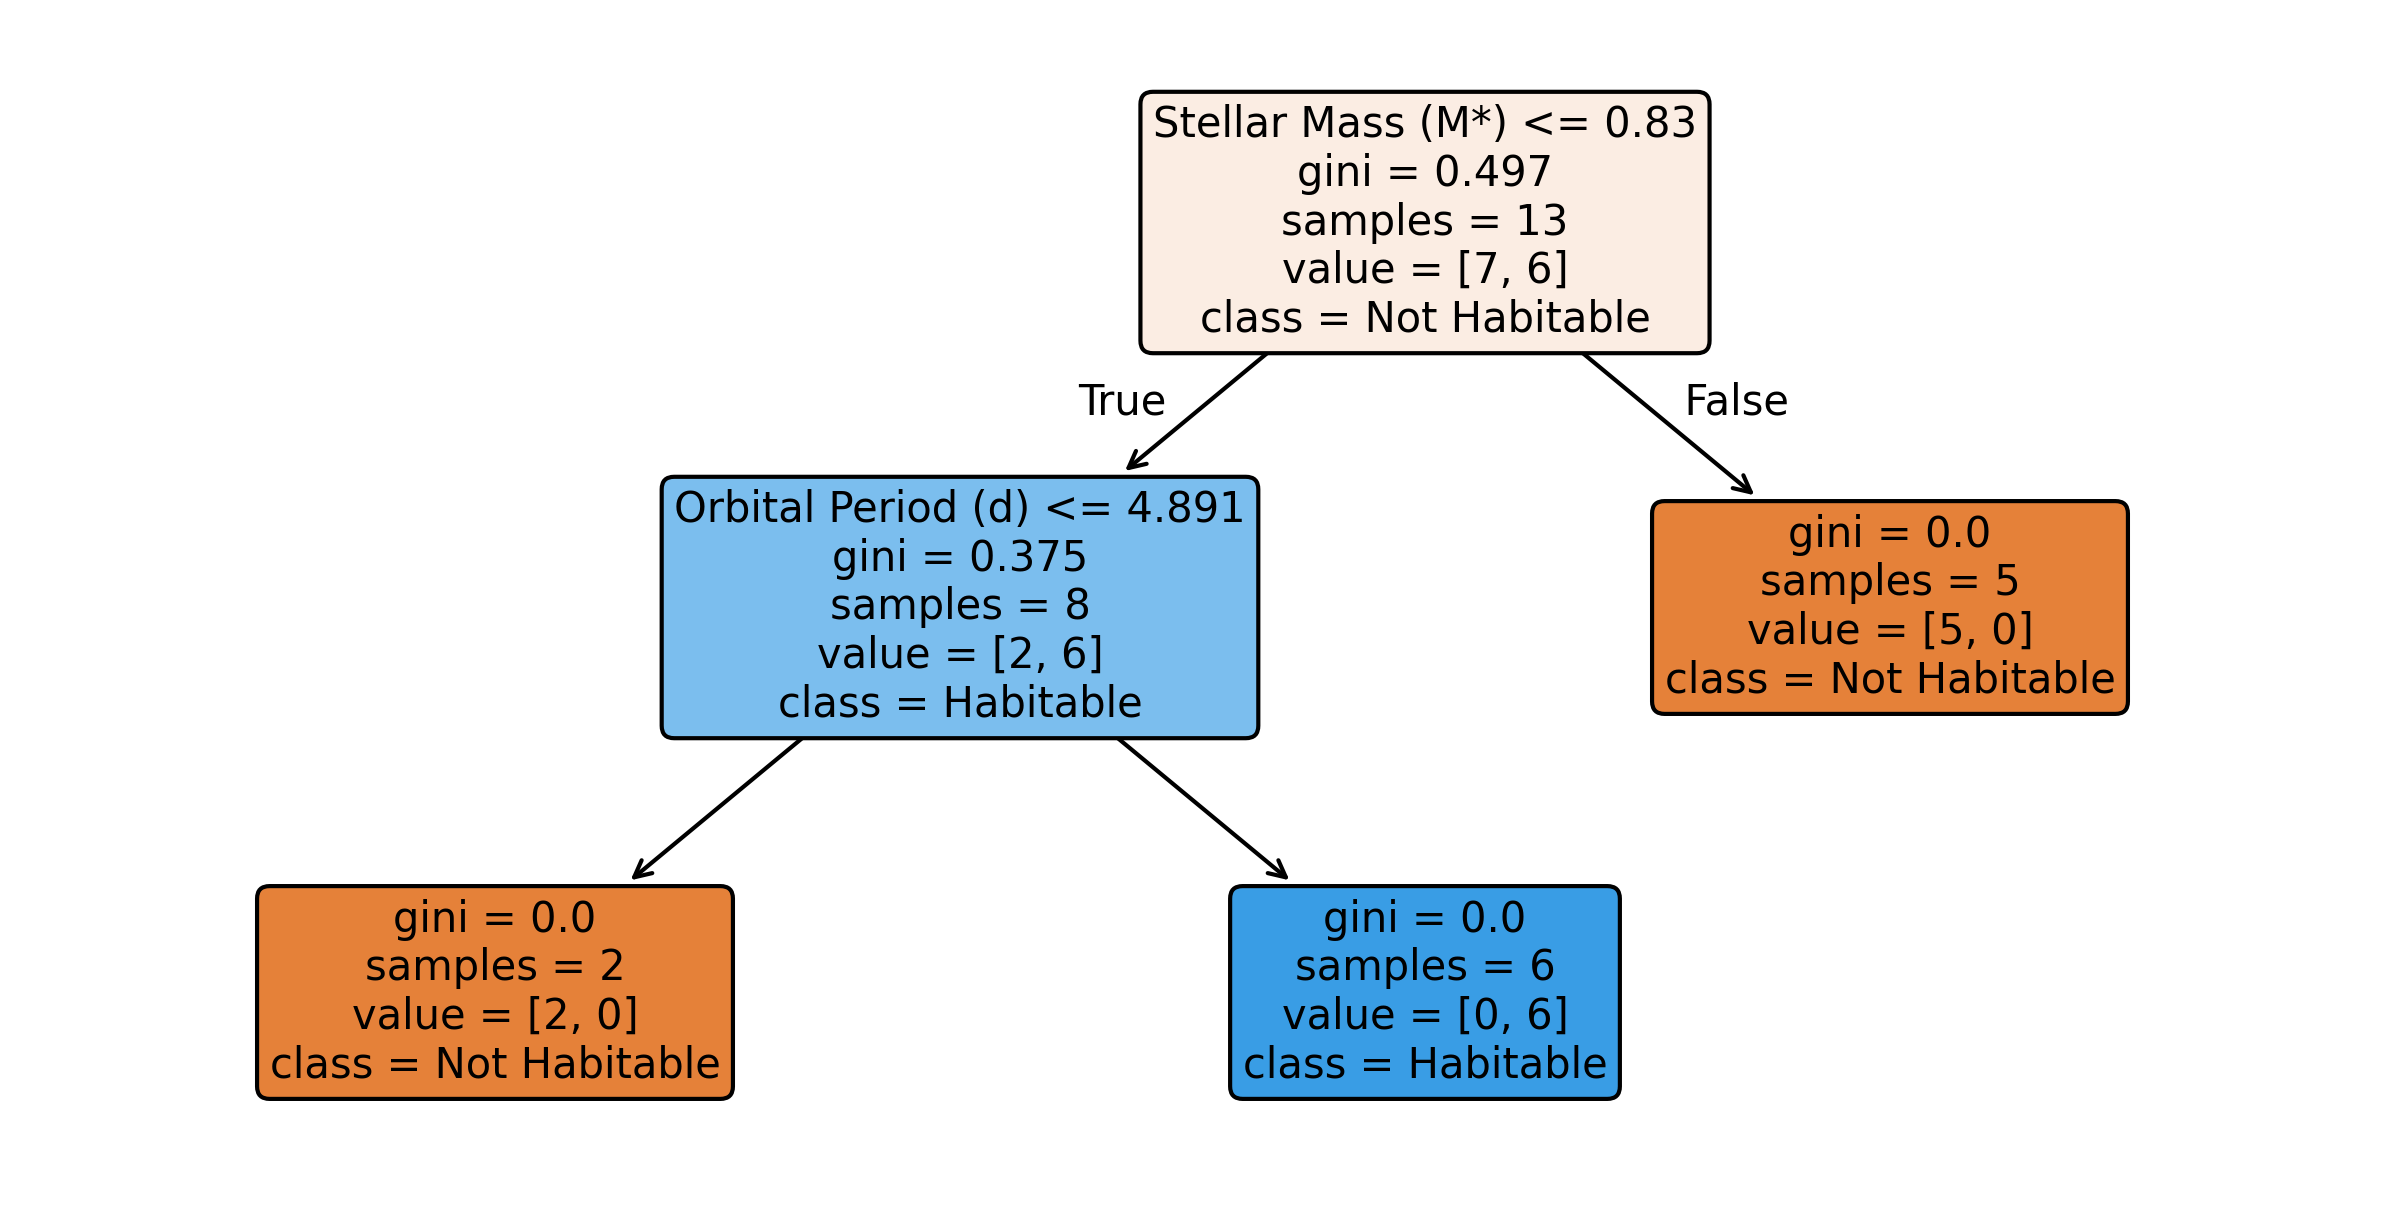

In [94]:
from sklearn import tree

plt.figure(figsize=(10,5))  # puede cambiar de acuerdo al tamaño del árbol
tree.plot_tree(model,
               feature_names = ['Stellar Mass (M*)', 'Orbital Period (d)', 'Distance (AU)'],
               class_names = ['Not Habitable','Habitable'],
               filled=True,
               rounded=True,
               fontsize=10)

plt.show()

### También podemos visualizar las decisiones del clasificador. El color de sombreado predice la etiqueta, y el color de los puntos marca la etiqueta real:

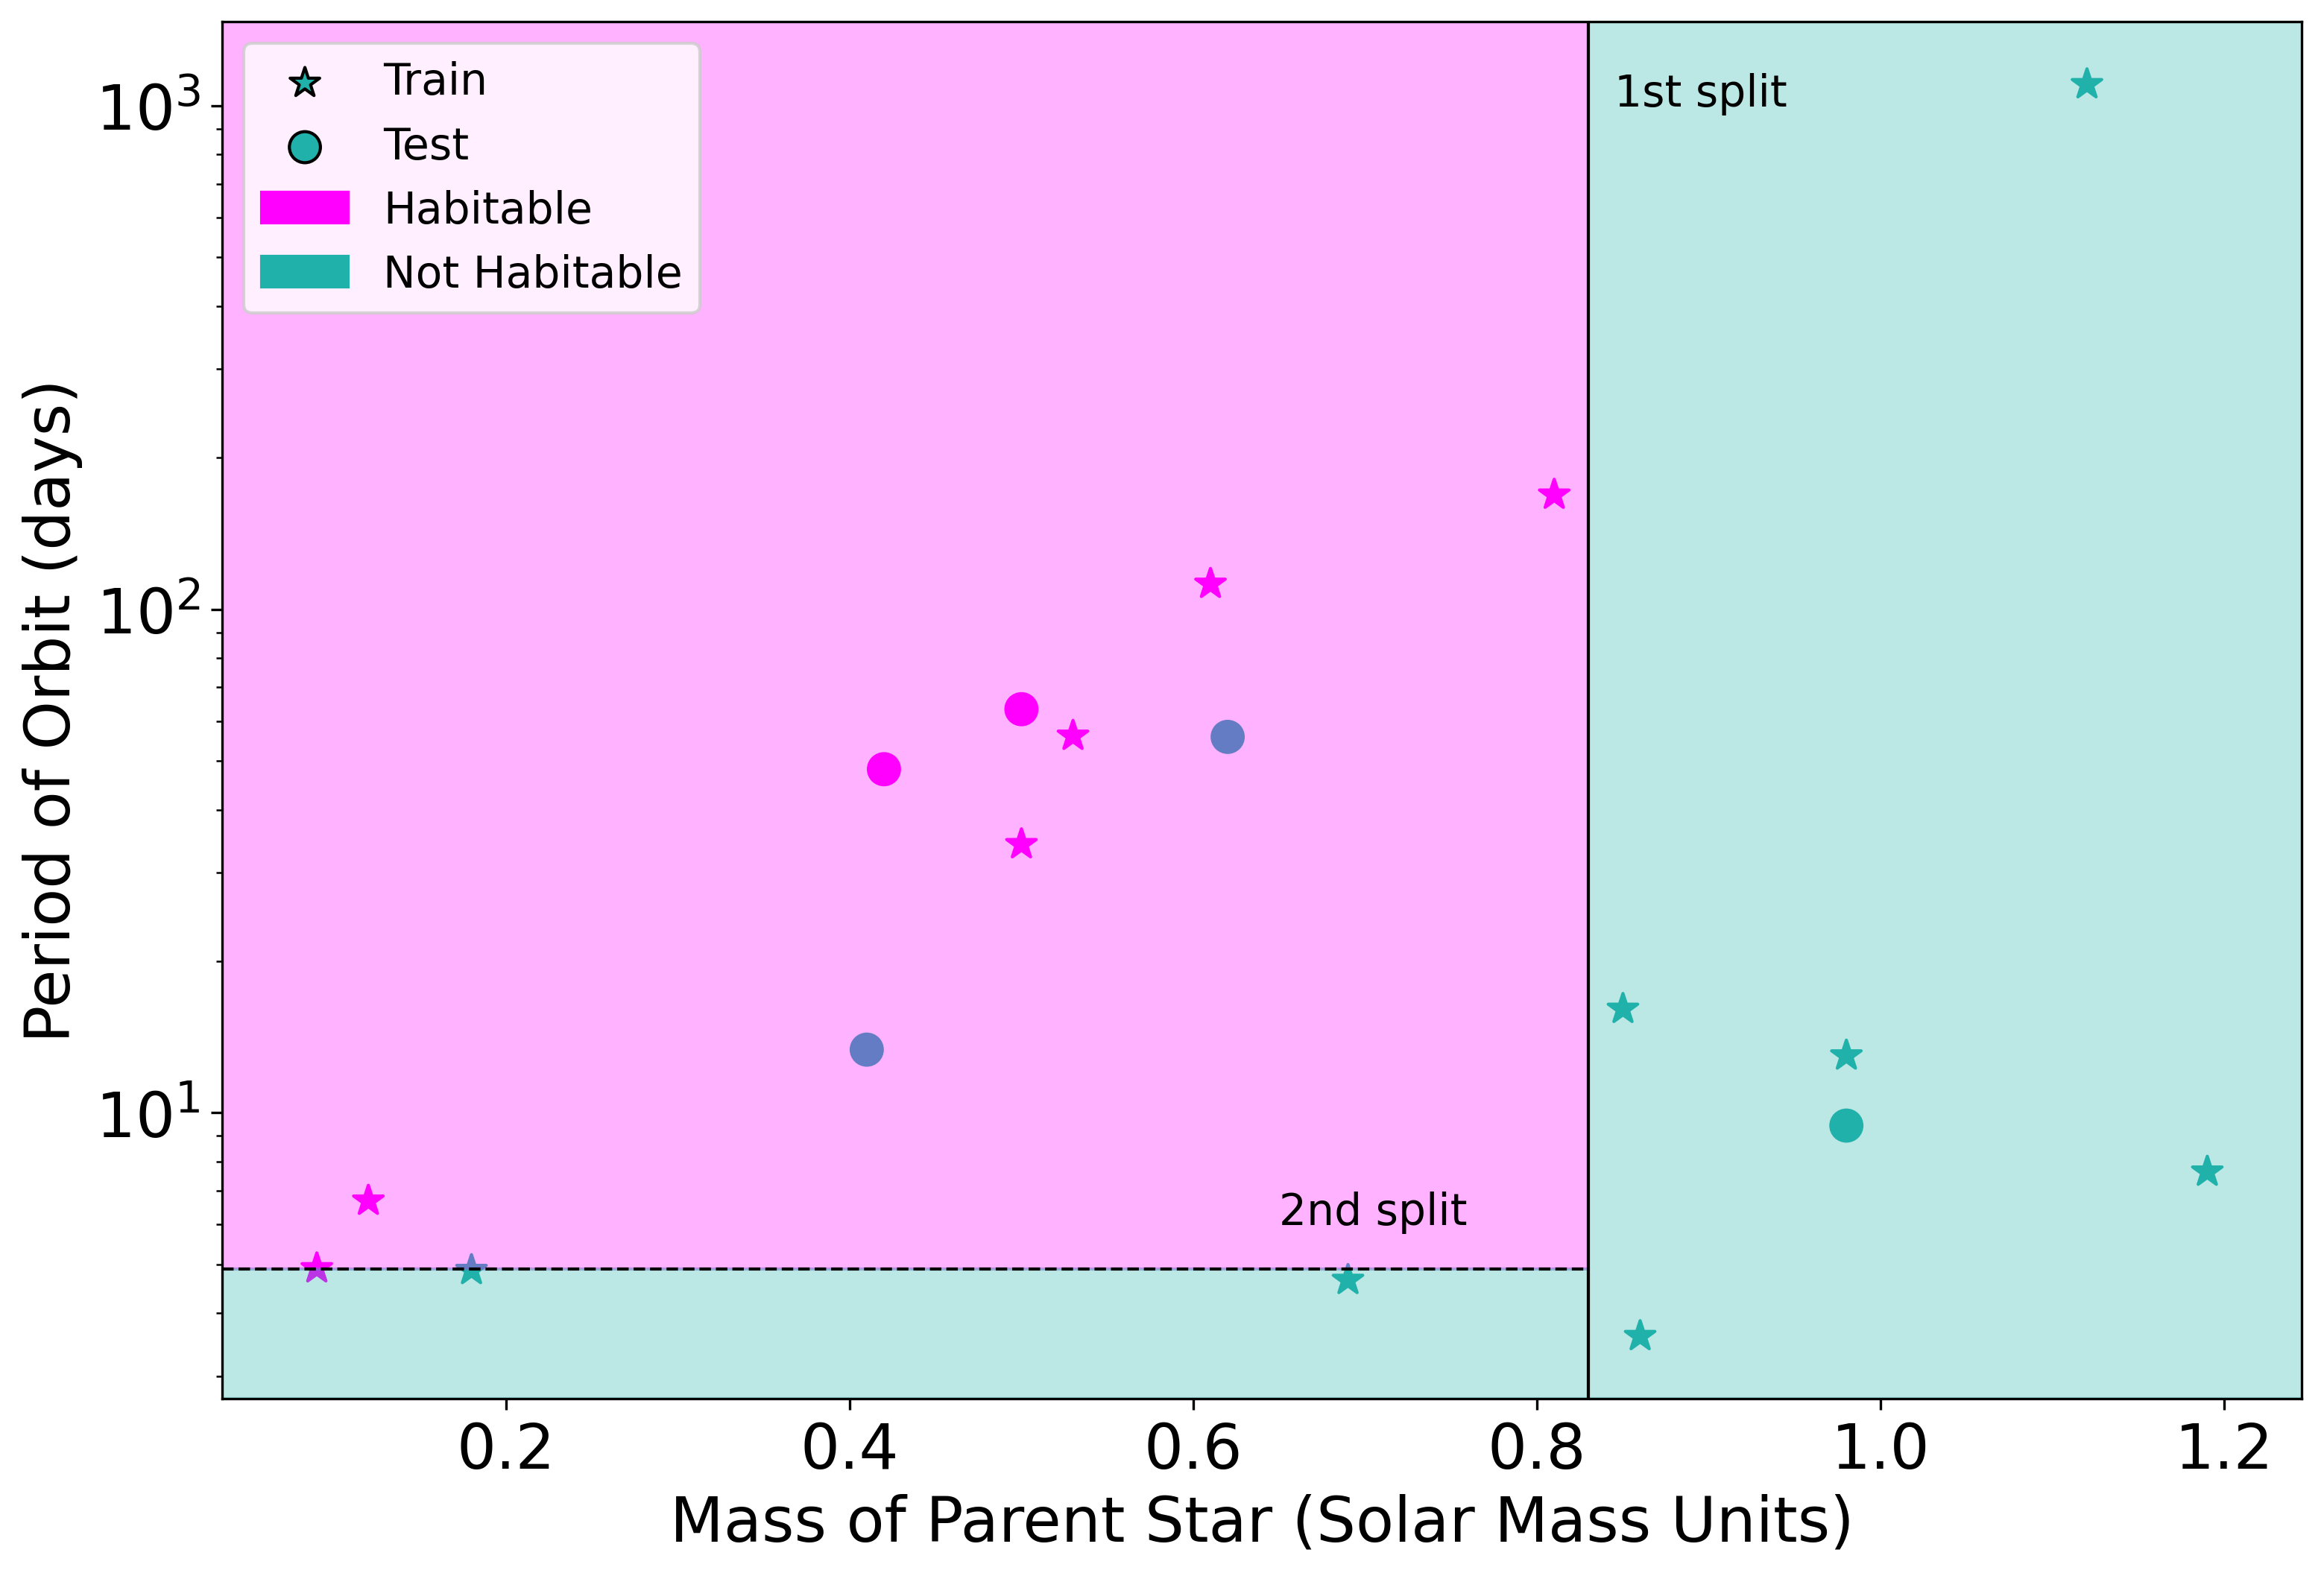

In [95]:
plt.figure(figsize=(12,8))

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

#puntos de entrenamiento y prueba

plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',\
            c = TrainSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Train')

plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',\
            c = TestSet['P_HABITABLE'], s = 100, cmap=cmap, label = 'Test')

plt.yscale('log')

plt.xlabel('Mass of Parent Star (Solar Mass Units)')

plt.ylabel('Period of Orbit (days)');

#splits del gráfico

plt.axvline(x=0.83, linewidth =1, ls = '-', label = '1st split', c='k')

plt.axhline(y=4.891, xmin = 0, xmax = 0.655, linewidth =1, ls = '--', label = '2nd split',c='k')

plt.text(0.845, 10**3, '1st split', fontsize=14)
         
plt.text(0.65, 6, '2nd split', fontsize=14)

#leyenda

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')

magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()

predhab = mpatches.Rectangle((0,4.891),0.83,ax.get_ylim()[1], 
                        fill = True,
                        color = '#FF00FF',
                        alpha = 0.3)

prednothab1 = mpatches.Rectangle((0.83,ax.get_ylim()[0]),ax.get_xlim()[1],ax.get_ylim()[1], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

prednothab2 = mpatches.Rectangle((0,ax.get_ylim()[0]),0.83,4.891-ax.get_ylim()[0], 
                        fill = True,
                        color = '#20B2AA',
                        alpha = 0.3)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')

plt.gca().add_patch(predhab)
plt.gca().add_patch(prednothab1)
plt.gca().add_patch(prednothab2)

leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[1].set_color('k')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14);


### Pregunta 
    
- ¿Cuál es el porcentaje de clasificaciones correctas en el set de entrenamiento?  Y en el set de prueba?


A este porcentaje de clasificaciones correctas lo llamaremos **accuracy**

### usando la métricas de sklearn, podemos encontrar el accuracy


In [96]:
import sklearn.metrics as metrics

In [97]:
ypred = model.predict(Xtest) #generamos etiquetas de predicción en el set de prueba

In [98]:
ypred

array([1, 1, 1, 0, 1])

Accuracy es una métrica usual para evaluar modelos de clasificación, y hay una función en el módulo `sklearn.metrics`. Tenemos que comparar los resultados de la predicción `ypred` con los valores reales `ytest`

In [99]:
metrics.accuracy_score(ytest, ypred) #test score

0.6

también podemos encontrar el accuracy de los datos de entrenamiento, generando predicciones para los `Xtrain` y comparando con el `ytrain`

In [100]:
metrics.accuracy_score(ytrain, model.predict(Xtrain)) #train score

1.0

### Preguntas de interpretación
1. ¿El árbol clasifica perfectamente el conjunto de entrenamiento?
2. ¿Qué ocurre en el conjunto de prueba?
3. ¿Qué variable aparece en la raíz del árbol?
4. ¿Te parece que este árbol es simple o ya es relativamente profundo para un dataset tan pequeño?


1. Sí,cuando dejamos que un árbol de decisión crezca sin restricciones (sin podarlo), encuentra las reglas para clasificar correctamente el 100% de los datos de entrenamiento
2. El accuracy suele ser menor. Esto se debe a que el modelo se memorizó los detalles exactos del conjunto de entrenamiento y pierde capacidad para "generalizar" con datos nuevos. Esto es overfitting.
3. Observando el gráfico, la primera partición se hace usando la Masa Estelar (S_MASS).
4. Para un dataset de 13 ejemplos de entrenamiento, un árbol con múltiples niveles de profundidad ya puede llegar a ser complejo y es muy propenso a sobreajustarse.

### Ahora elegiremos un set de entrenamiento distinto. Las 5 primeras filas serán de prueba y el resto será para el entrenamiento

In [101]:
# los primeros 5 de prueba, el resto de entrenamiento
TrainSet2 = LearningSet.iloc[5:,:] 
TestSet2 = LearningSet.iloc[:5,:]

### Repita el proceso anterior

1. Defina los dataframes de características y la serie de categorías para entrenamiento y prueba: `Xtrain2`, `Xtest2`, `ytrain2`, `ytest2`
2. inicialice el modelo de árbol de decisión para clasificación (defina semilla `random_state=3`
3. ajuste el modelo a los datos de entrenamiento
4. visualice el árbol
5. calcule accuracy para entrenamiento y prueba

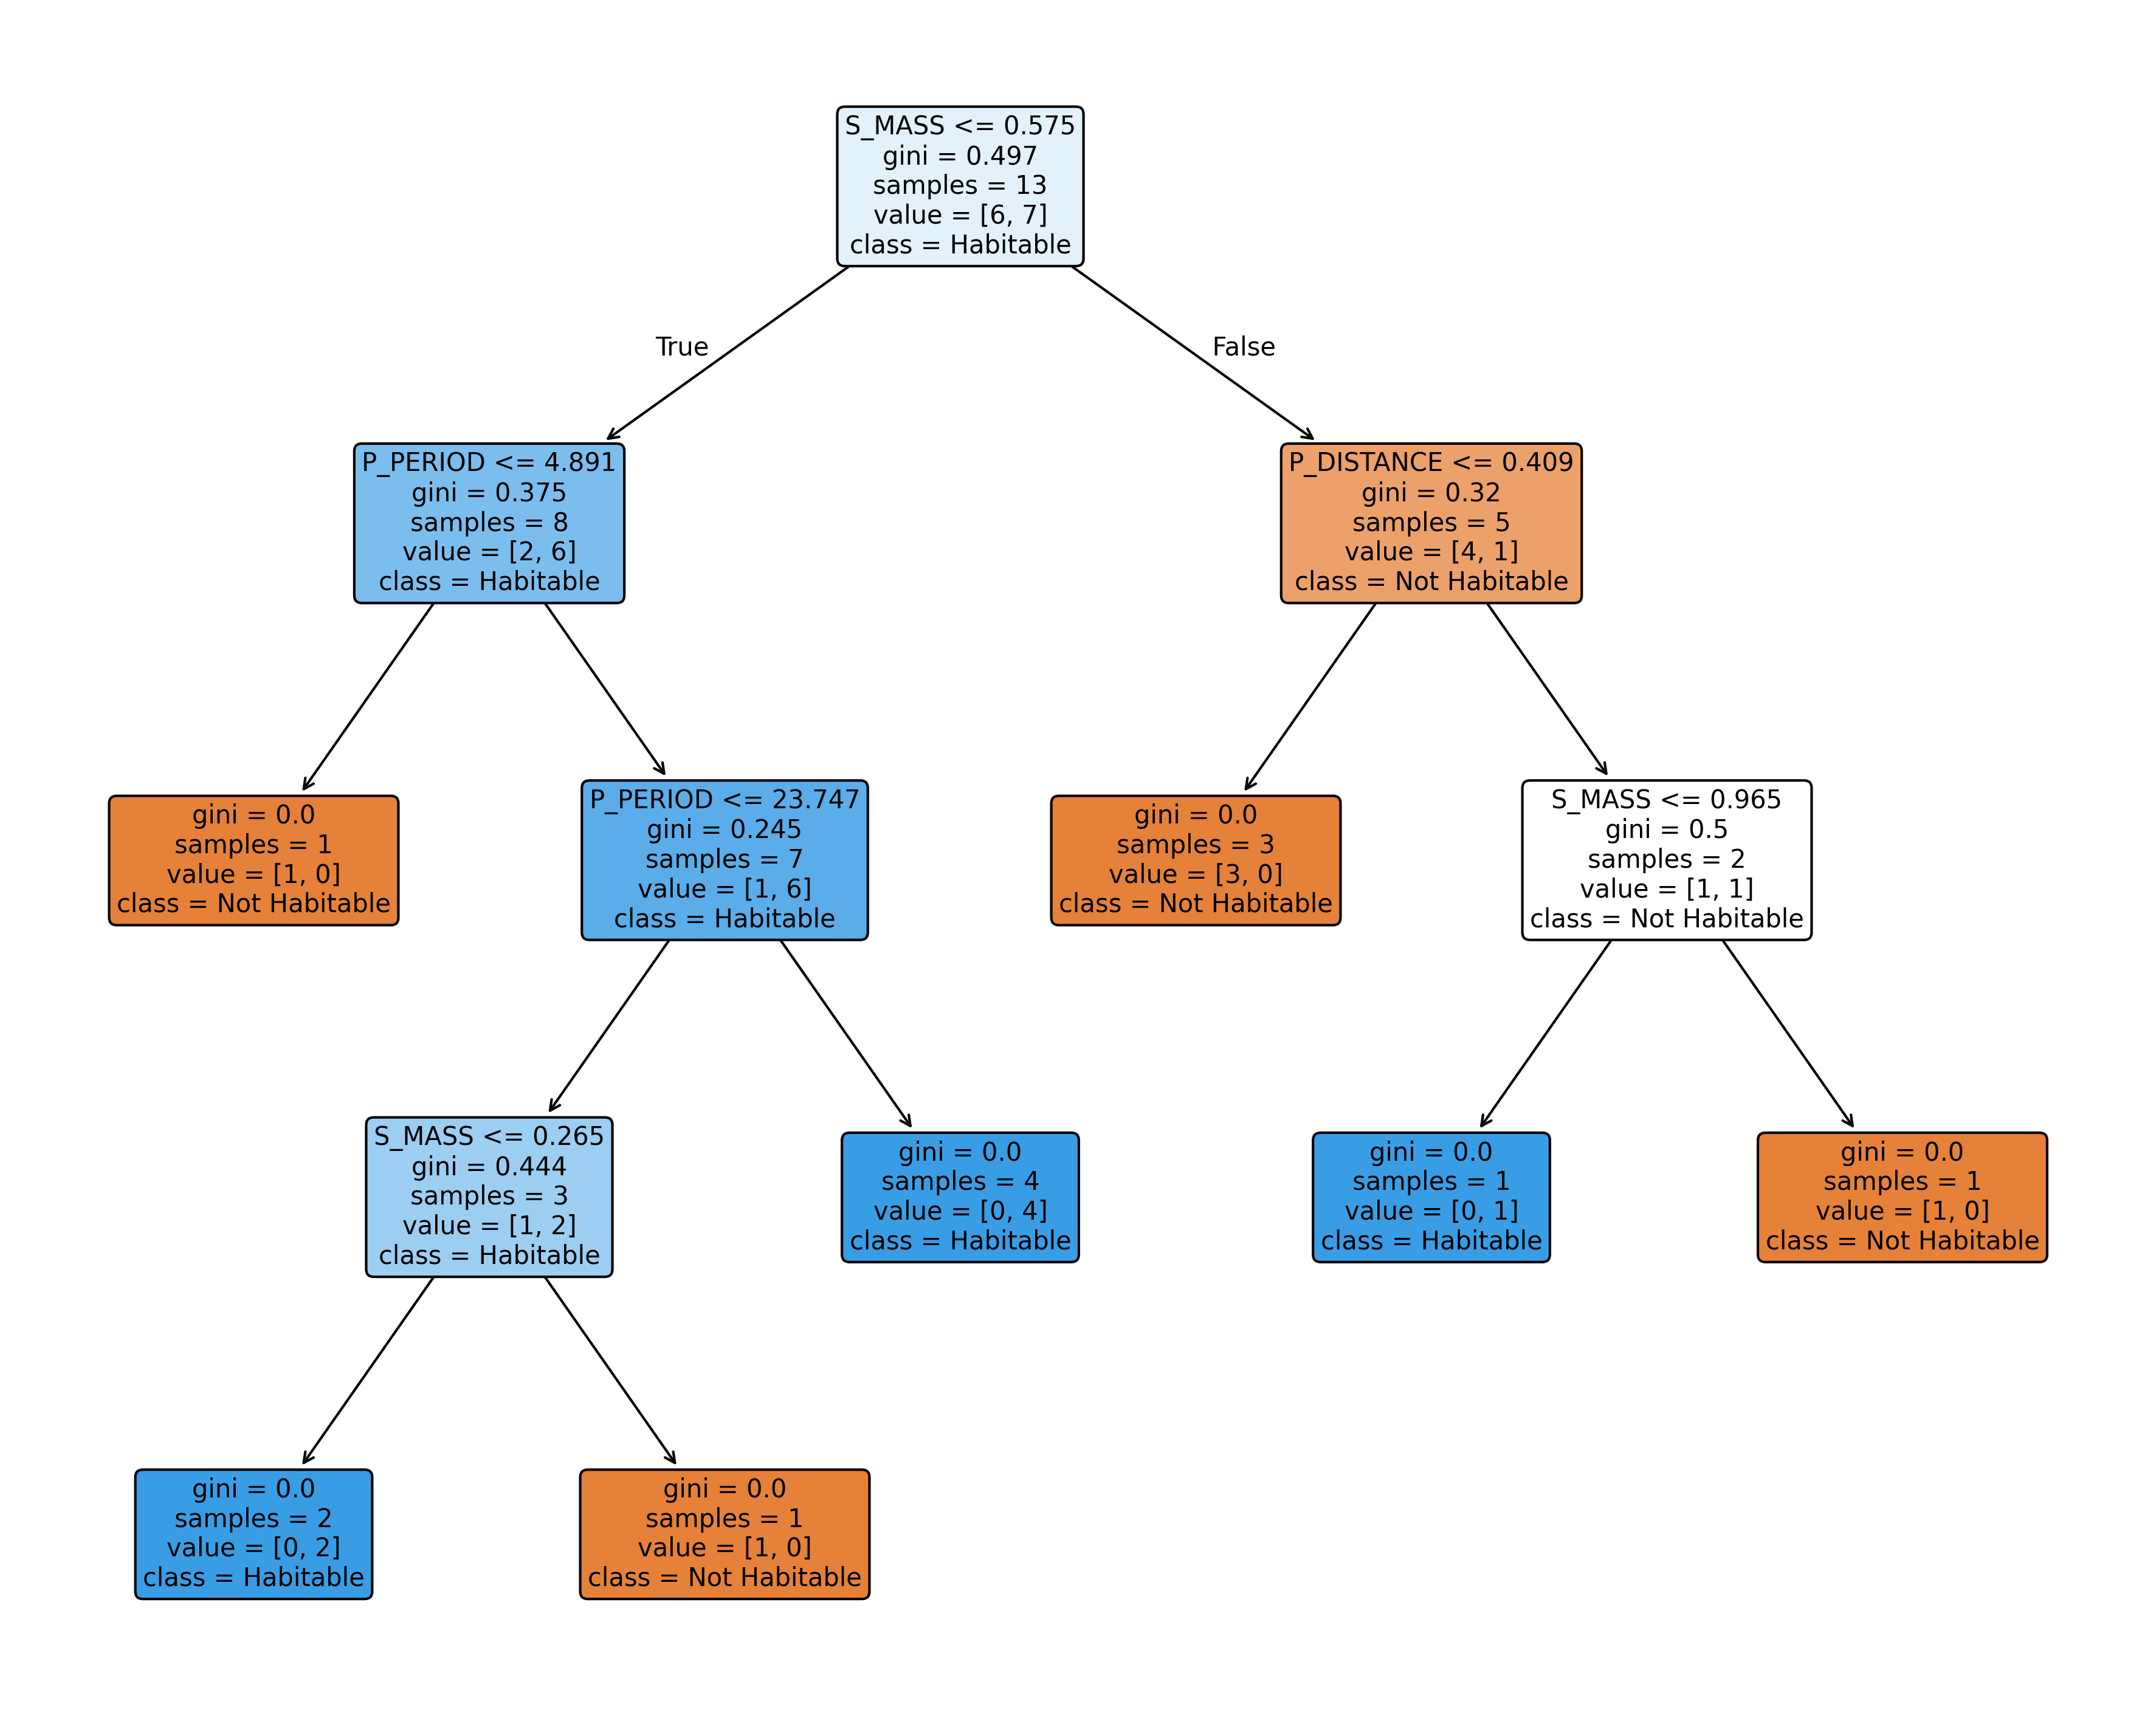

Accuracy Entrenamiento (Set 2): 1.0
Accuracy Prueba (Set 2): 1.0


In [102]:
Xtrain2 = TrainSet2.drop(['P_NAME','P_HABITABLE'], axis=1)
Xtest2 = TestSet2.drop(['P_NAME','P_HABITABLE'], axis=1)
ytrain2 = TrainSet2.P_HABITABLE
ytest2 = TestSet2.P_HABITABLE

model2 = DecisionTreeClassifier(random_state=3)
model2.fit(Xtrain2, ytrain2)

plt.figure(figsize=(15,12))
tree.plot_tree(model2,
               feature_names=['S_MASS', 'P_PERIOD', 'P_DISTANCE'],
               class_names=['Not Habitable','Habitable'],
               filled=True, rounded=True, fontsize=10)
plt.show()

acc_train2 = metrics.accuracy_score(ytrain2, model2.predict(Xtrain2))
acc_test2 = metrics.accuracy_score(ytest2, model2.predict(Xtest2))

print(f"Accuracy Entrenamiento (Set 2): {acc_train2}")
print(f"Accuracy Prueba (Set 2): {acc_test2}")

### Preguntas:

- Compare el árbol de decisión inicial vs el obtenido ahora. Nota alguna diferencia?

- ¿Cuál es el accuracy (porcentaje de clasificaciones correctas) en el conjunto de entrenamiento? 

- ¿Y en el conjunto de prueba?

- Si ahora el resultado es mejor, ¿significa automáticamente que este árbol es “mejor” en general?


1. Sí, al cambiar solo 5 datos (nuestro nuevo set de entrenamiento), el árbol cambia de forma dramática, es mas grande, las reglas y los puntos de corte se modifican. Esto demuestra la enorme inestabilidad de los árboles cuando tienen muy pocos datos
2. 1.0 (100%) tanto en entrenamiento como en prueba
3. No. Al tener un conjunto de prueba tan chico (solo 5 datos), tener un 100% no significa que el modelo generalice bien en el mundo real. Es muy probable que estos 5 planetas justos hayan sido "fáciles" de clasificar para este árbol específico, pero el modelo en sí sigue sufriendo de la misma alta varianza

### Conclusiones

- Que puede concluir respecto a al ejercicio?

- Cambian los resultados dependiendo del set de datos que utilizamos?

- ¿Sería la Tierra clasificada como habitable por alguno de estos árboles?

1. Los árboles de decisión son buenos para visualizar las fronteras físicas del problema, pero en datasets pequeños son altamente inestables y tienden al sobreajuste rápidamente
2. Si. Vimos que intercambiar apenas unos pocos datos de entrenamiento/prueba alteró todo el árbol y cambió el accuracy de prueba
3. Lo mas probable es que no por el primer árbol. El primer árbol descarta los planetas si la masa estelar (S_MASS) es mayor a 0.83 (y el sol de la Tierra es masa 1.0), por lo que la clasificaría como no habitable producto del sobreajuste de sus reglas

## k-Nearest Neighbors 

Aplicaremos ahora kNN al mismo problema.

>kNN clasifica según las etiquetas de los `k` vecinos más cercanos, es un método basado en distancia, por eso la **escala** de las variables sí importa.




In [103]:
from sklearn import neighbors 
import sklearn

Para el mismo set de datos de habitabilidad de planetas

In [104]:
Xtrain

,S_MASS,P_PERIOD,P_DISTANCE
0,0.86,3.601472,0.043718
1,0.85,16.080661,0.118082
2,1.19,7.638460,0.080420
3,0.61,112.305300,0.409327
4,0.98,12.992073,0.107408
5,0.09,4.910000,0.025200
6,0.69,4.655411,0.048086
7,0.12,6.689000,0.035000
8,1.12,1103.000000,2.180981
9,0.81,168.811170,0.557107


### "Entrenamos" el modelo
Es un algoritmo sencillo basado en la idea de distancia: buscamos los k (un número entero) objetos que están más cerca del que queremos clasificar, y tomamos la votación de la mayoría entre las k clases de los k vecinos.

kNN es un algoritmo basado en instancias (también llamado **"lazy learning"**), sigue necesitando saber con qué datos va a comparar para hacer predicciones futuras. El método fit le dice al algoritmo con qué datos va a trabajar.

El método fit en kNN no ajusta parámetros del modelo como en otros algoritmos.
Simplemente almacena los datos de entrenamiento para su uso durante la predicción.
Durante la predicción, el algoritmo calcula las distancias entre el nuevo punto y los puntos de entrenamiento almacenados para encontrar los k vecinos más cercanos y decidir la clase del nuevo punto basado en una votación mayoritaria.
En esencia, el proceso de "ajuste" en kNN es solo la configuración de los datos de referencia para comparaciones futuras, no un ajuste de parámetros basado en optimización.









In [105]:
model = neighbors.KNeighborsClassifier(n_neighbors = 3) #elegimos los 3 vecinos más cercanos

In [106]:
model

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Para propósitos de visualización, usemos solo las dos primeras características para construir el modelo.

In [107]:
Xtrain.iloc[:,:2] 

,S_MASS,P_PERIOD
0,0.86,3.601472
1,0.85,16.080661
2,1.19,7.638460
3,0.61,112.305300
4,0.98,12.992073
5,0.09,4.910000
6,0.69,4.655411
7,0.12,6.689000
8,1.12,1103.000000
9,0.81,168.811170


#### Se construye el modelo aplicando el método .fit al conjunto de entrenamiento. Luego, predice las etiquetas para el conjunto de prueba.

In [108]:
model.fit(Xtrain.iloc[:,:2],ytrain) #esto ajusta el modelo que se usa para hacer predicciones en nuevas instancias
ytestpred = model.predict(Xtest.iloc[:,:2]) #esto ajsta el modelo en los datos de prueba

In [109]:
ytestpred, ytest.values #comparacion

(array([1, 0, 1, 0, 1]), array([0, 0, 1, 0, 1]))

#### Calculando accuracy en los sets de entrenamiento y prueba

In [110]:
print(metrics.accuracy_score(ytrain, model.predict(Xtrain.iloc[:,:2]))) #Esto compara las etiquetas reales del set de entrenamiento con las etiquetas predichas para el test de entrenamiento
print(metrics.accuracy_score(ytest, model.predict(Xtest.iloc[:,:2]))) #mismo que anterior, pero para set de prueba

0.6923076923076923
0.8


#### Después de ajustar y la predicción, podemos ver los k neighbors que encontró el modelo en el conjunto de prueba

In [111]:
model.kneighbors(Xtest.iloc[:,:2]) #el primer elemento es la distancia, el segundo los índices de cada vecinos

(array([[ 0.26575741, 21.66422235, 39.72600482],
        [ 0.67412717,  2.76390862,  5.76653597],
        [ 7.28027781, 29.19416   , 47.25690512],
        [ 1.807928  ,  2.87670841,  3.5579225 ],
        [ 7.9223177 , 13.99261869, 32.05672308]]),
 array([[11, 10,  1],
        [ 4,  1,  2],
        [11, 10,  1],
        [ 2,  7,  4],
        [11, 10,  1]]))

### Visualizando los resultados

USamos la distancia del tercer vecino como el radio del círculo que encierra vecinos


In [112]:
for i in range(len(TestSet)): # para cada elemento del set de prueba
    
    print(model.kneighbors(Xtest.iloc[:,:2])[0][i,2]) # muestra el tercer elemento del vector de distancia

39.7260048163029
5.766535965914376
47.2569051246575
3.5579225
32.05672308015779


El siguiente código dibuja un círculo incluyendo a los 3 vecinos más cercanos para cada punto

### Nota: Para la aplicación real (no la visualización), debiéramos usar todas las features disponibles 

C:\Users\User\AppData\Local\Temp\ipykernel_2608\665978696.py:5: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
C:\Users\User\AppData\Local\Temp\ipykernel_2608\665978696.py:8: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\


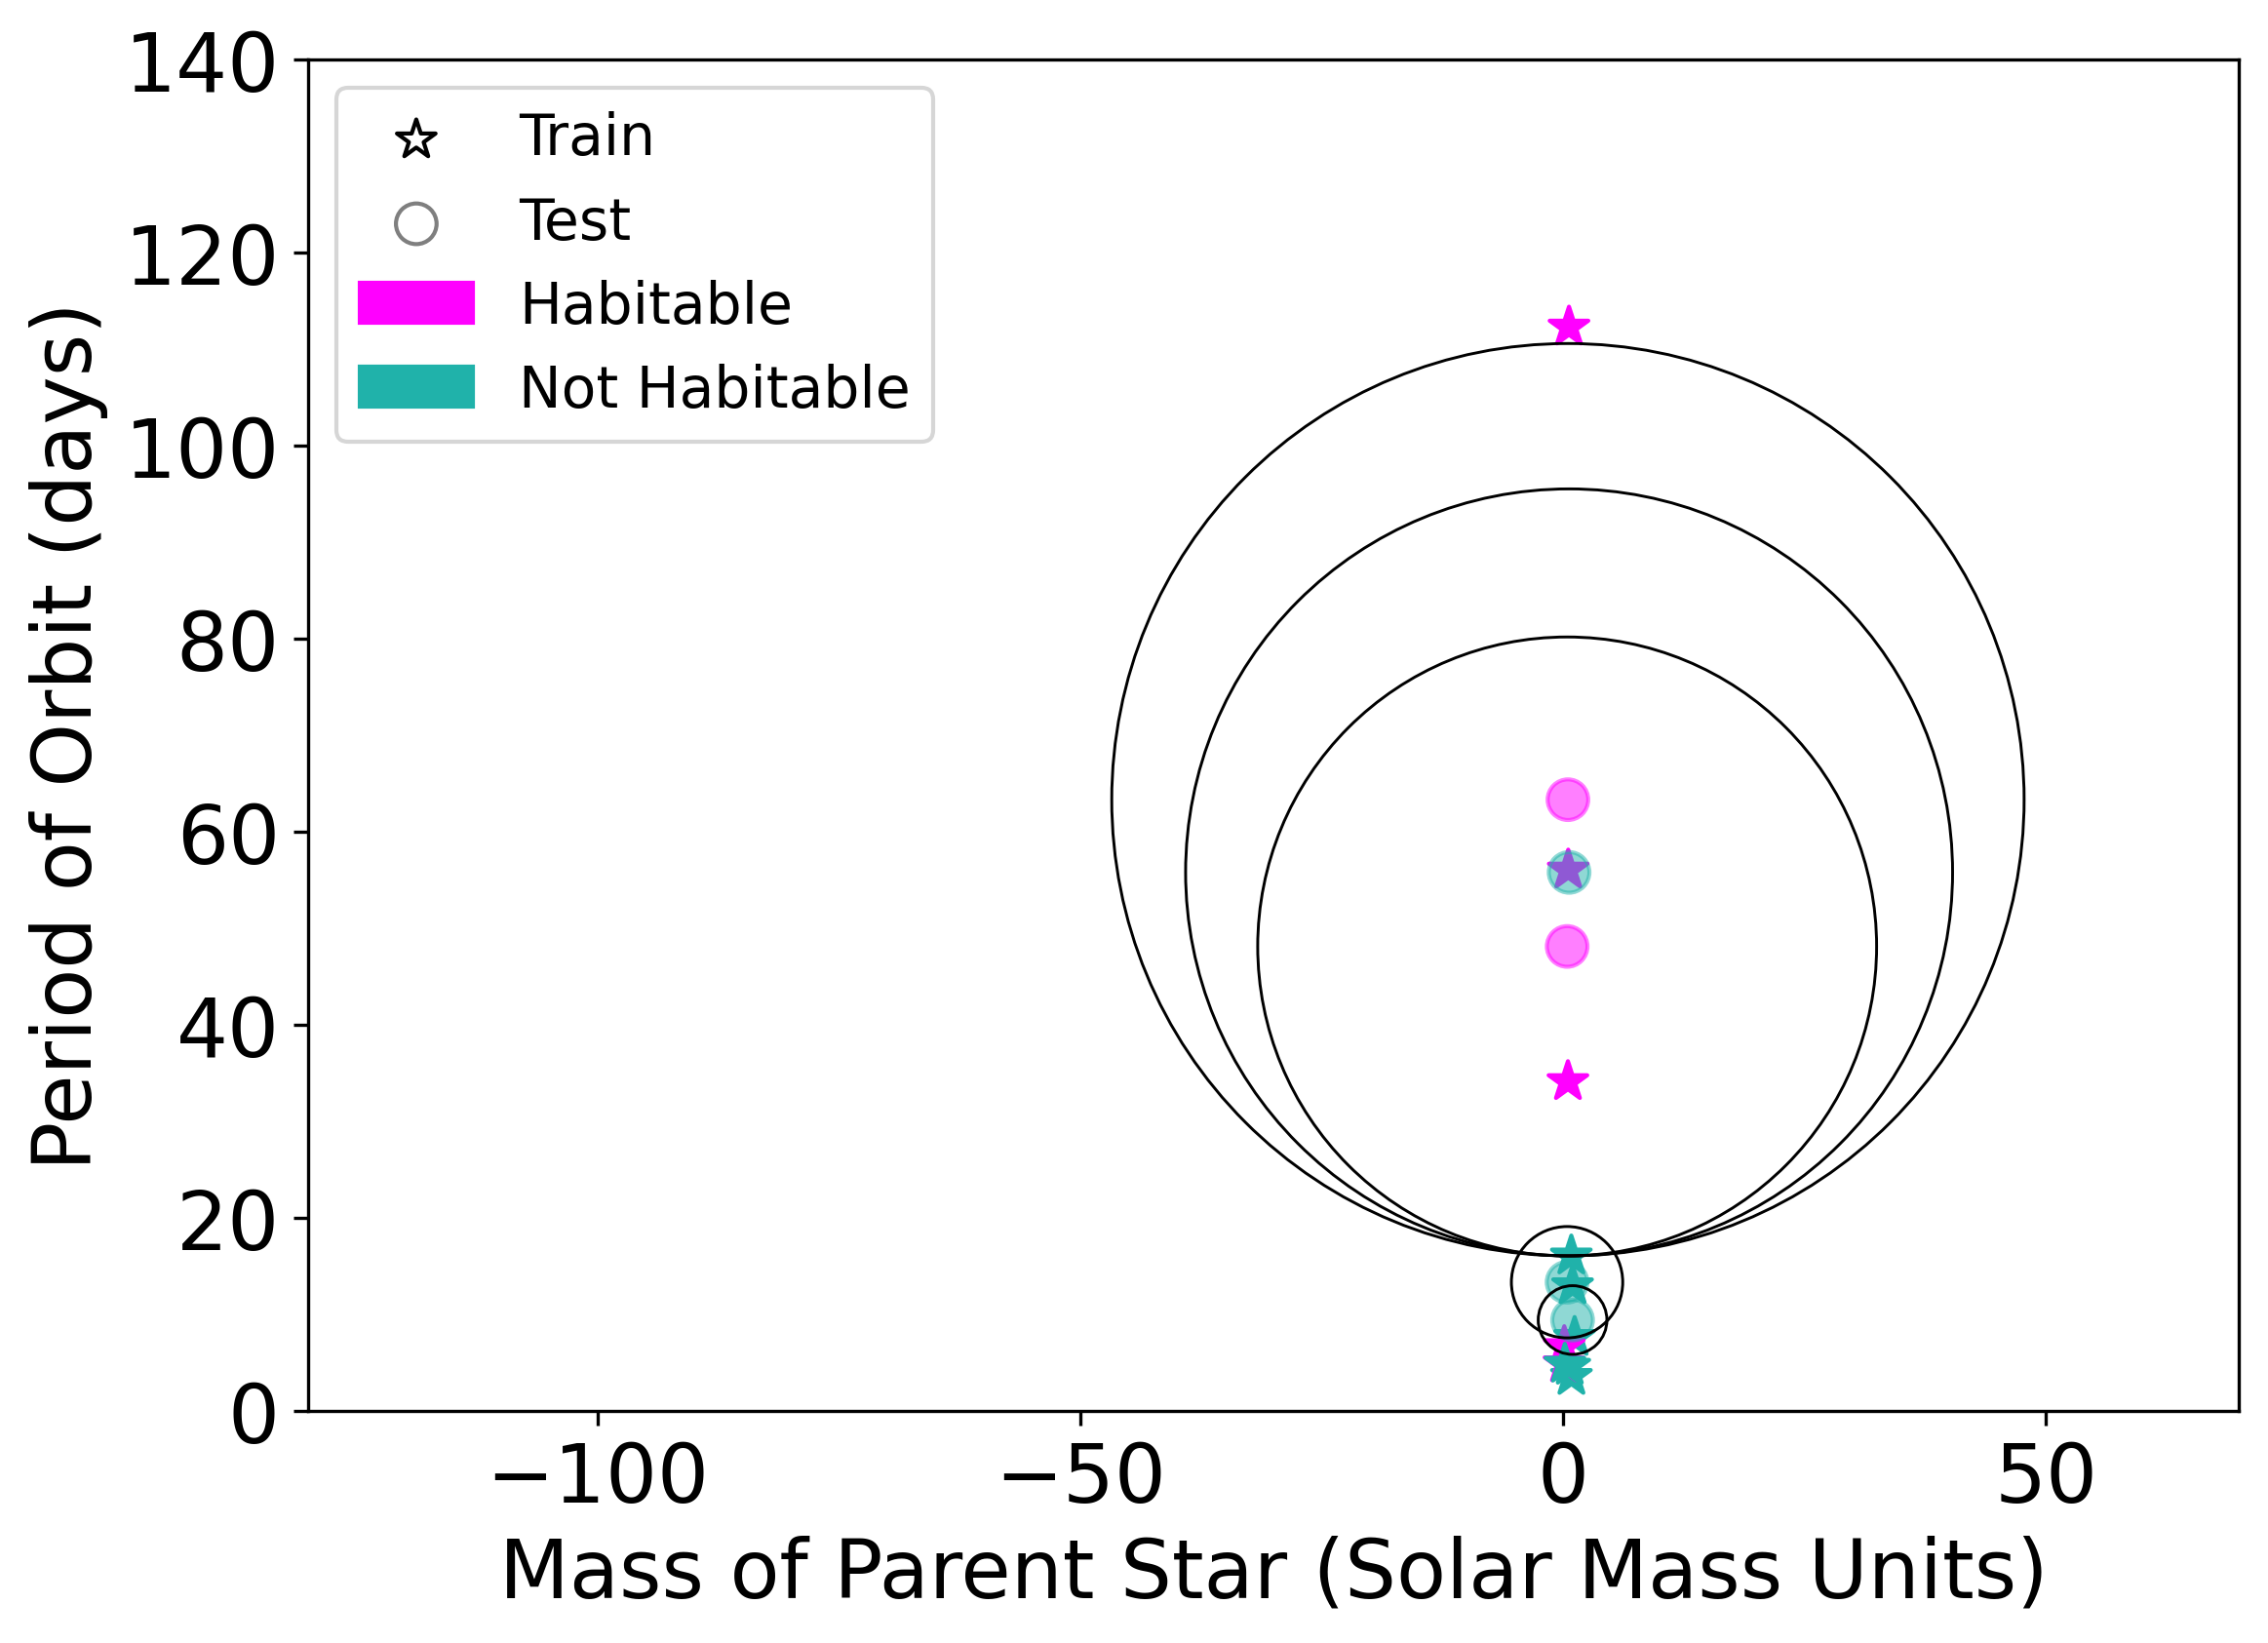

In [113]:
plt.figure(figsize=(10,6))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])


a= plt.scatter(TrainSet['S_MASS'], TrainSet['P_PERIOD'], marker = '*',facecolor = 'None',\
            c = TrainSet['P_HABITABLE'], s = 100, label = 'Train', cmap=cmap) 

a= plt.scatter(TestSet['S_MASS'], TestSet['P_PERIOD'], marker = 'o',facecolor = 'None',\
            c = TestSet['P_HABITABLE'], s = 100, label = 'Test', cmap=cmap, alpha=0.5) 

for i in range(len(TestSet)): 

    circle1=plt.Circle((TestSet['S_MASS'].iloc[i],TestSet['P_PERIOD'].iloc[i]),model.kneighbors(Xtest.iloc[:,:2])[0][i,2],\
                       lw = 0.7, edgecolor='k',facecolor='none')
    plt.gca().add_artist(circle1)
    
plt.gca().set_aspect(1)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

plt.legend();

ax = plt.gca()
leg = ax.get_legend()
leg.legend_handles[0].set_color('k')
leg.legend_handles[0].set_facecolor('none')
leg.legend_handles[1].set_color('k')
leg.legend_handles[1].set_facecolor('none')


plt.legend(handles=[leg.legend_handles[0],leg.legend_handles[1], magentapatch, bluepatch],\
           loc = 'upper left', fontsize = 14)

plt.xlim(-130,70)
plt.ylim(0,140)
plt.xlabel('Mass of Parent Star (Solar Mass Units)')
plt.ylabel('Period of Orbit (days)');


### Nota algo particular en el gráfico?

 **Si una dimensión tiene un rango mucho mayor que las otras, dominará el proceso de decisión. Este problema se puede solucionar mediante el <b>escalado</b>. El escalado es un paso de preprocesamiento muy importante para la mayoría de los algoritmos de aprendizaje automático.**



Algunos ejemplos de algoritmos de Scaler [aquí](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html).

Usaremos [`RobustScaler()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html), que se comporta mejor con outliers que la versión estándar, ya que escala de acuerdo a percentiles. Específicamente, usa la mediana (percentil 50) y el rango intercuartílico (IQR = Q3 - Q1), lo cual lo hace menos sensible a valores extremos


In [114]:
scaler = sklearn.preprocessing.RobustScaler() #inicializamos el Scaler

#### Importante!!

Debemos ajustar el escalador **sólo con los datos de entrenamiento**. Esto se hace porque **el modelo no debe tener acceso a los datos de prueba durante el entrenamiento**. Si usamos los datos de prueba para ajustar el escalador, estaríamos filtrando información del futuro, lo que se conoce como data leakage.

Esto puede llevar a dos problemas: por un lado, el modelo podría parecer más preciso de lo que realmente es, y por otro, podría aprender patrones que no se generalizan bien a datos nuevos, lo que se traduce en sobreajuste.

Para evitar esto, primero se ajusta el escalador con los datos de entrenamiento (`fit`), y luego se usa ese mismo escalador para transformar tanto el entrenamiento como el test (`transform`).

In [115]:
scaler.fit(Xtrain) # importante: solo escalamos el set de entrenamiento

,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False


In [116]:
scaledXTrain = scaler.transform(Xtrain)

In [117]:
scaledXTrain

array([[ 0.47222222, -0.18360363, -0.33840183],
       [ 0.44444444,  0.06038761,  0.05671512],
       [ 1.38888889, -0.10467304, -0.14339694],
       [-0.22222222,  1.94175736,  1.60417741],
       [ 0.80555556,  0.        ,  0.        ],
       [-1.66666667, -0.15801948, -0.43679409],
       [ 0.        , -0.16299717, -0.31519247],
       [-1.58333333, -0.12323674, -0.38472405],
       [ 1.19444444, 21.311672  , 11.01745224],
       [ 0.33333333,  3.04655169,  2.38937206],
       [-0.52777778,  0.41352236,  0.3761471 ],
       [-0.44444444,  0.84198052,  0.66159817],
       [-1.41666667, -0.15877753, -0.40201197]])

In [118]:
scaledXtest = scaler.transform(Xtest) # 

In [119]:
scaler.inverse_transform #esto invierte el escalado si es necesario

<bound method RobustScaler.inverse_transform of RobustScaler()>

**Ahora, con los datos escalados, aplique el modelo de kNN inicializado anteriormente, genere las predicciones y genere la misma visualización que en el caso anterior**

In [120]:
model_knn_2_scaled = neighbors.KNeighborsClassifier(n_neighbors=3)

model_knn_2_scaled.fit(scaledXTrain[:,:2], ytrain)

ytestpred_scaled = model_knn_2_scaled.predict(scaledXtest[:,:2])

print("Accuracy Entrenamiento kNN (2 variables escaladas):", metrics.accuracy_score(ytrain, model_knn_2_scaled.predict(scaledXTrain[:,:2])))
print("Accuracy Prueba kNN (2 variables escaladas):", metrics.accuracy_score(ytest, ytestpred_scaled))

Accuracy Entrenamiento kNN (2 variables escaladas): 0.8461538461538461
Accuracy Prueba kNN (2 variables escaladas): 0.8


C:\Users\User\AppData\Local\Temp\ipykernel_2608\4164760577.py:10: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(scaledXTrain[:,0], scaledXTrain[:,1], marker='*', facecolors='none', edgecolors='k',
C:\Users\User\AppData\Local\Temp\ipykernel_2608\4164760577.py:13: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(scaledXtest[:,0], scaledXtest[:,1], marker='o', facecolors='none', edgecolors='k',


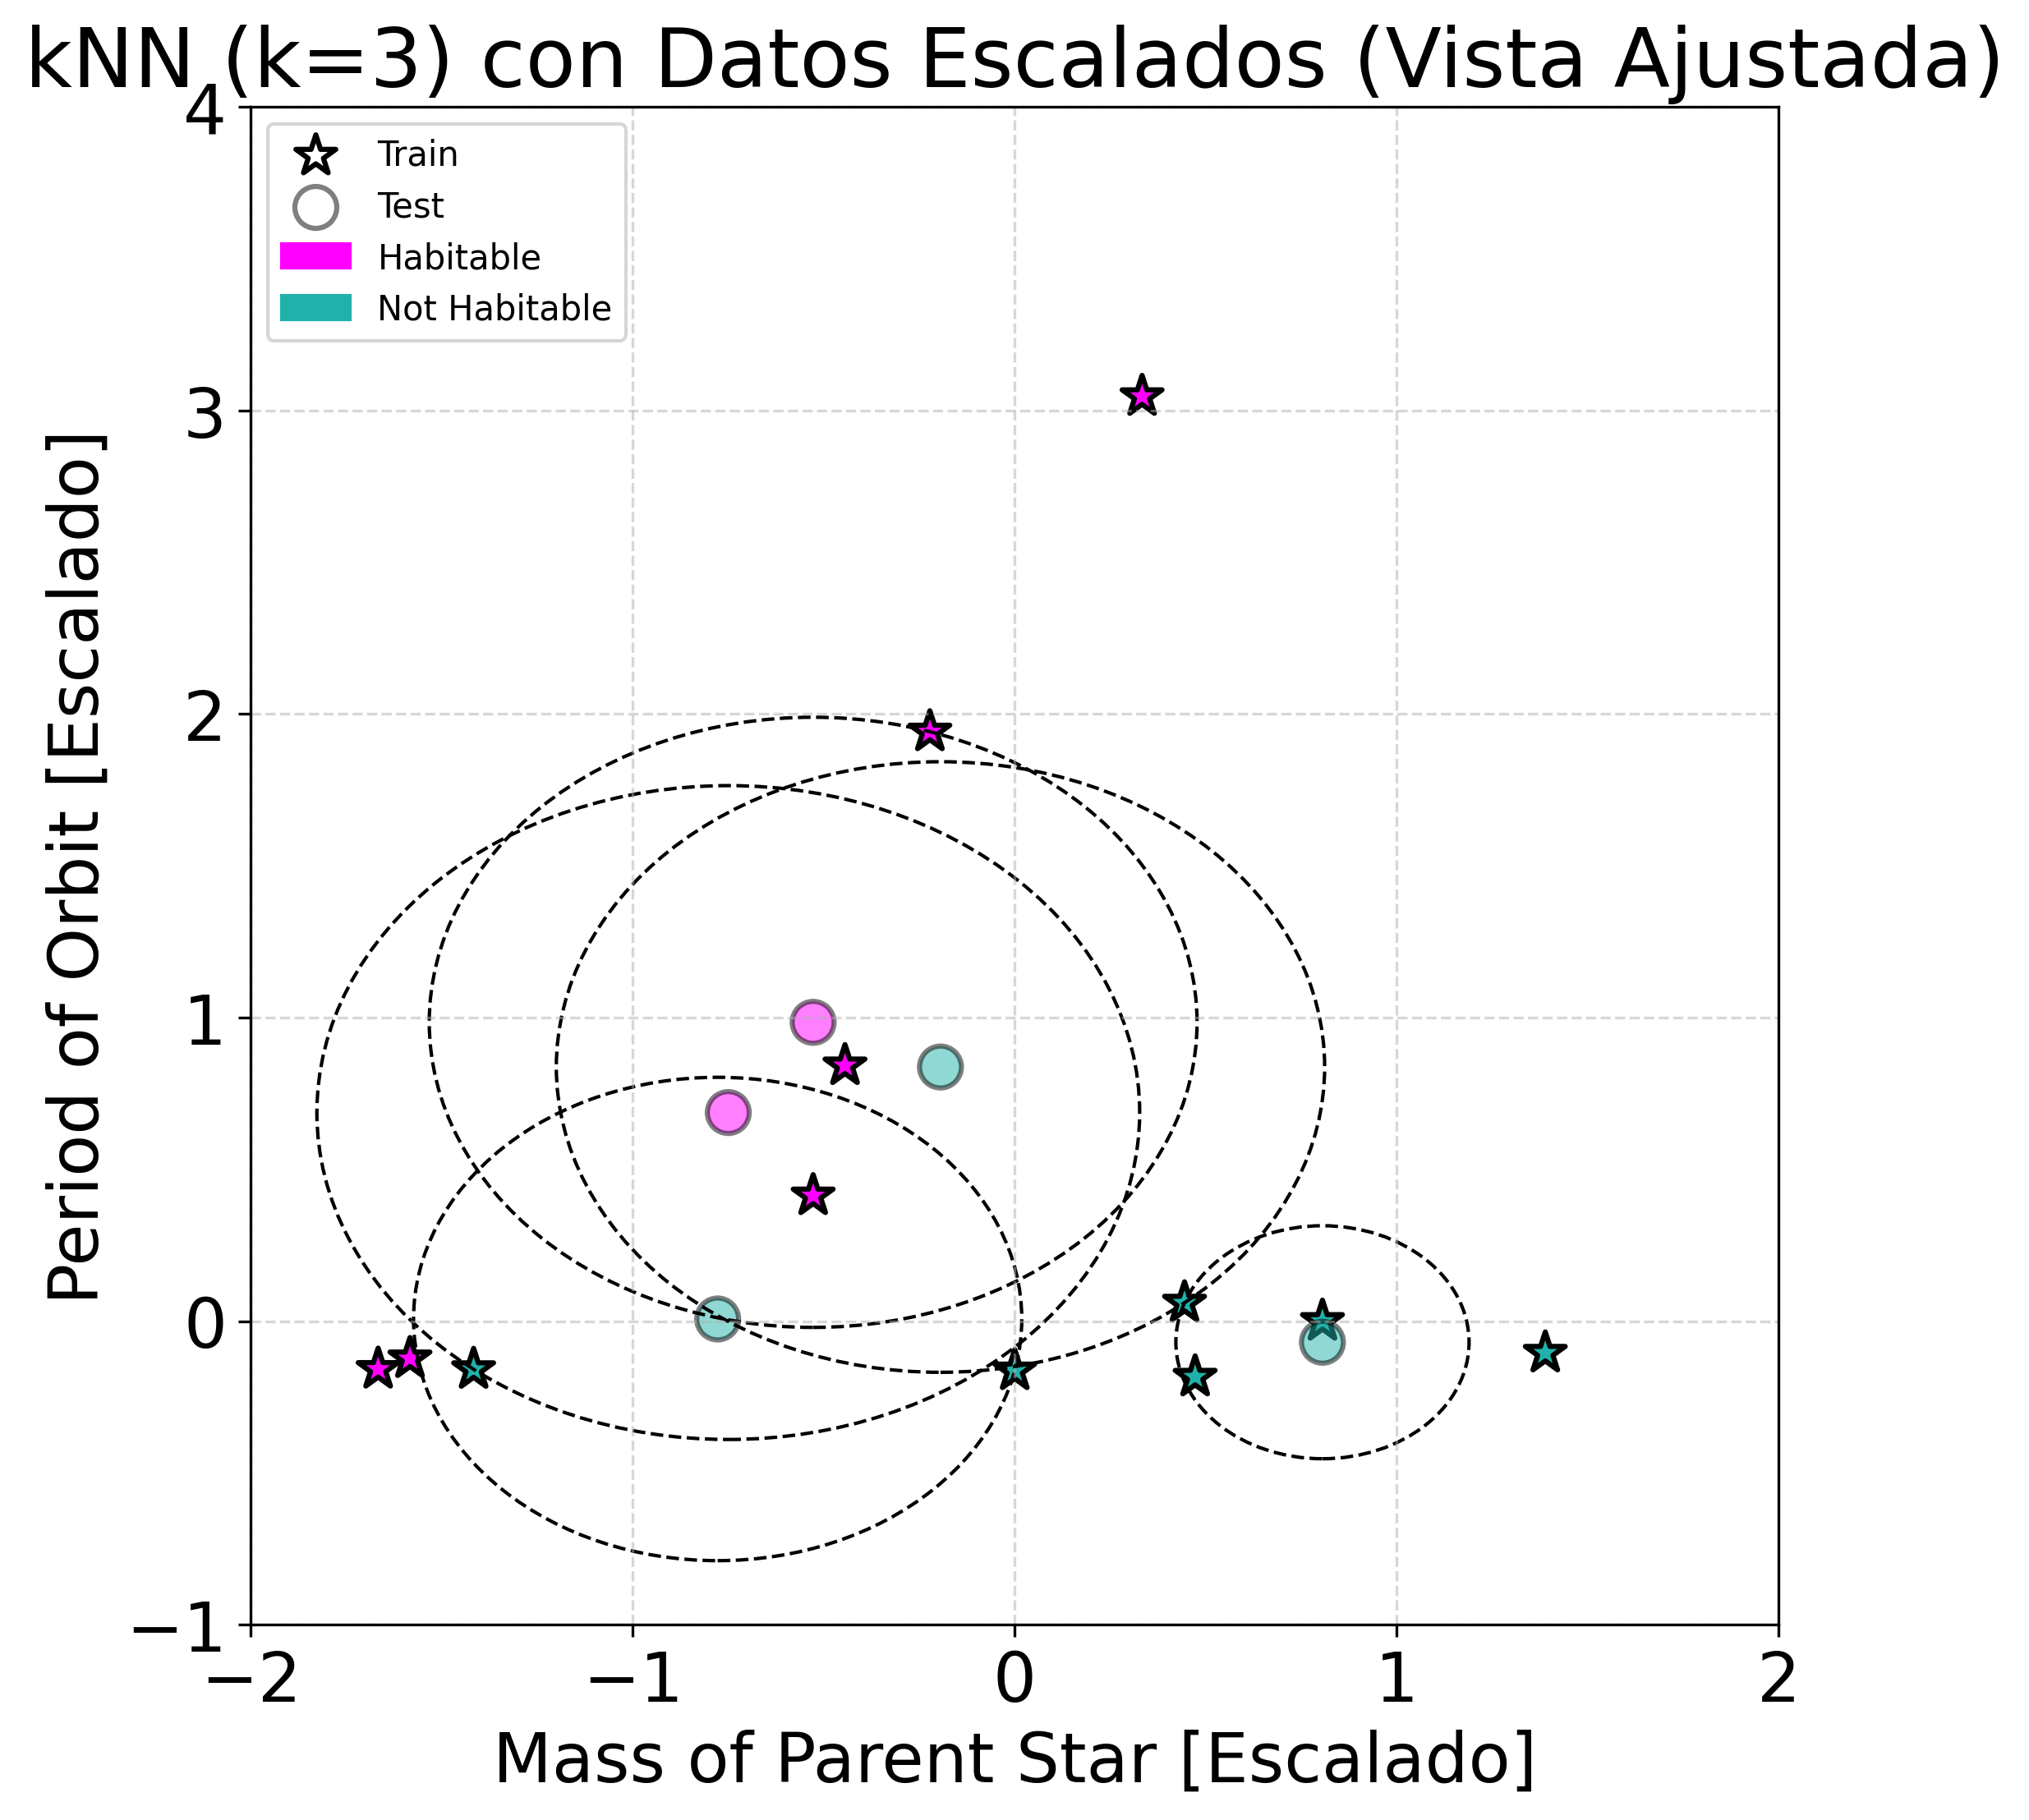

In [121]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.colors

distancias_escaladas, vecinos_escalados = model_knn_2_scaled.kneighbors(scaledXtest[:,:2])

plt.figure(figsize=(8, 8))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#20B2AA','#FF00FF'])

plt.scatter(scaledXTrain[:,0], scaledXTrain[:,1], marker='*', facecolors='none', edgecolors='k',
            c=ytrain, s=150, label='Train', cmap=cmap, linewidths=1.5) 

plt.scatter(scaledXtest[:,0], scaledXtest[:,1], marker='o', facecolors='none', edgecolors='k',
            c=ytest, s=150, label='Test', cmap=cmap, alpha=0.5, linewidths=1.5) 

for i in range(len(ytest)): 
    radio = distancias_escaladas[i, 2] 
    circle = plt.Circle((scaledXtest[i, 0], scaledXtest[i, 1]), radio,
                        lw=1, edgecolor='k', facecolor='none', linestyle='--')
    plt.gca().add_artist(circle)
    
plt.gca().set_aspect('auto') 

plt.ylim(-1, 4) 
plt.xlim(-2, 2)

bluepatch = mpatches.Patch(color='#20B2AA', label='Not Habitable')
magentapatch = mpatches.Patch(color='#FF00FF', label='Habitable')

ax = plt.gca()
leg = ax.legend(loc='upper left', fontsize=12)
if len(leg.legend_handles) >= 2:
    leg.legend_handles[0].set_color('k')
    leg.legend_handles[0].set_facecolor('none')
    leg.legend_handles[1].set_color('k')
    leg.legend_handles[1].set_facecolor('none')

plt.legend(handles=[leg.legend_handles[0], leg.legend_handles[1], magentapatch, bluepatch],
           loc='upper left', fontsize=10)

plt.xlabel('Mass of Parent Star [Escalado]')
plt.ylabel('Period of Orbit [Escalado]')
plt.title('kNN (k=3) con Datos Escalados (Vista Ajustada)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Repita el proceso de kNN escalado, pero usando todas las caracteristicas, y compare el accuracy**

In [122]:
model_knn_all = neighbors.KNeighborsClassifier(n_neighbors=3)

model_knn_all.fit(scaledXTrain, ytrain)

ytestpred_all = model_knn_all.predict(scaledXtest)

print("Accuracy Entrenamiento kNN (TODAS las variables):", metrics.accuracy_score(ytrain, model_knn_all.predict(scaledXTrain)))
print("Accuracy Prueba kNN (TODAS las variables):", metrics.accuracy_score(ytest, ytestpred_all))

Accuracy Entrenamiento kNN (TODAS las variables): 0.8461538461538461
Accuracy Prueba kNN (TODAS las variables): 0.8


### Preguntas 

- Descubrimos que kNN necesita escalado ¿DT tiene el mismo problema?

- Compare las fortalezas y debilidades de DT y kNN

- ¿Qué diferencia conceptual hay entre cómo clasifica un árbol de decisión y cómo clasifica kNN?

- ¿Por qué el accuracy en entrenamiento no basta para evaluar un modelo?

- ¿Por qué kNN requiere escalamiento y un árbol de decisión no necesariamente?

- Si tuvieras que elegir uno de los dos métodos para este dataset pequeño, ¿cuál elegirías y por qué?


1. No. Los árboles de decisión cortan los datos usando desigualdades de forma separada. La magnitud del eje no distorsiona las decisiones del árbol
2. DT: Es interpretable y no necesita escalado. Lo malo es la alta inestabilidad de las reglas y el sobreajuste.
kNN: Es un método intuitivo y logró un accuracy más estable (0.8 sostenido tras escalar). Sus debilidades son ser una caja negra (no sabemos por qué elige un planeta como habitable sin mirar el gráfico) y que falla sin escalado de datos
3. El árbol de decisión clasifica construyendo reglas jerárquicas exactas para dividir grupos (busca zonas puras). kNN clasifica un objeto nuevo asumiendo que "debe parecerse a los que tiene al lado" mediante un cálculo espacial de distancias
4. Porque (como vimos en el primer árbol) un modelo puede memorizar y obtener 1.0 (100%) en el entrenamiento, pero fallar al ver un caso nuevo en el set de prueba obteniendo 0.6
5. Porque kNN calcula distancias sumando todos los valores al mismo tiempo. Si no escalamos la variable con el número más grande dicta el resultado. Los árboles de decisión evalúan una sola variable a la vez, por lo que las escalas no interfieren entre sí
6. Para un dataset tan inestable, el kNN escalado demostró ser una alternativa matemáticamente más robusta, manteniendo un accuracy de 0.8 de forma coherente. El Árbol de decisión demostró demasiada varianza y sobreajuste